In [1]:
# 1. Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score, classification_report,
                             confusion_matrix)
from sklearn.preprocessing import StandardScaler

%matplotlib inline
sns.set(style='whitegrid')

In [2]:
# 2. Generate synthetic dataset that mimics NDVI & precipitation behavior
# We'll create a dataset of "pixels" with lat/lon, elevation, monthly precip and NDVI values over a year.
np.random.seed(42)
num_pixels = 800

def make_seasonal(months=12, amplitude=1.0, phase=0.0):
    m = np.arange(months)
    return amplitude * np.sin(2 * np.pi * (m/months) + phase)

# Pixel static features
lats = np.random.uniform(10.0, 20.0, size=num_pixels)   # example lat range
lons = np.random.uniform(75.0, 85.0, size=num_pixels)   # example lon range
elevation = np.random.uniform(0, 1500, size=num_pixels)
soil_type = np.random.choice([0,1,2], size=num_pixels, p=[0.5,0.3,0.2])  # categorical soil types

months = 12
records = []
for i in range(num_pixels):
    base_precip = np.interp(lats[i], [10,20], [800,400])  # rough lat-based precip gradient
    season = make_seasonal(months, amplitude=0.6, phase=np.random.rand()*2*np.pi)
    for m in range(months):
        precip = max(0, base_precip * (0.5 + 0.8*(season[m]+1)/2) + np.random.normal(0,40))
        # NDVI influenced by precip, elevation (negatively), soil type, and seasonal component
        ndvi_mean = 0.2 + 0.001*(-elevation[i]) + 0.0015*precip + 0.05*(soil_type[i]==1) - 0.03*(soil_type[i]==2)
        ndvi = np.clip(ndvi_mean + 0.12*season[m] + np.random.normal(0,0.05), -0.1, 0.95)
        records.append({
            'pixel_id': i,
            'lat': lats[i],
            'lon': lons[i],
            'elevation': elevation[i],
            'soil_type': soil_type[i],
            'month': m+1,
            'precip_mm': precip,
            'ndvi': ndvi
        })

df = pd.DataFrame.from_records(records)
df['year'] = 2024

print('Dataset shape:', df.shape)
df.head()

Dataset shape: (9600, 9)


,pixel_id,lat,lon,elevation,soil_type,month,precip_mm,ndvi,year
0,0,13.745401,82.072386,287.800987,0,1,477.785831,0.605900,2024
1,0,13.745401,82.072386,287.800987,0,2,483.723607,0.625619,2024
2,0,13.745401,82.072386,287.800987,0,3,438.871140,0.508011,2024
3,0,13.745401,82.072386,287.800987,0,4,422.237299,0.557111,2024
4,0,13.745401,82.072386,287.800987,0,5,439.110257,0.541782,2024


NDVI summary:


count    9600.000000
mean        0.324483
std         0.377917
min        -0.100000
25%        -0.100000
50%         0.273427
75%         0.655105
max         0.950000
Name: ndvi, dtype: float64

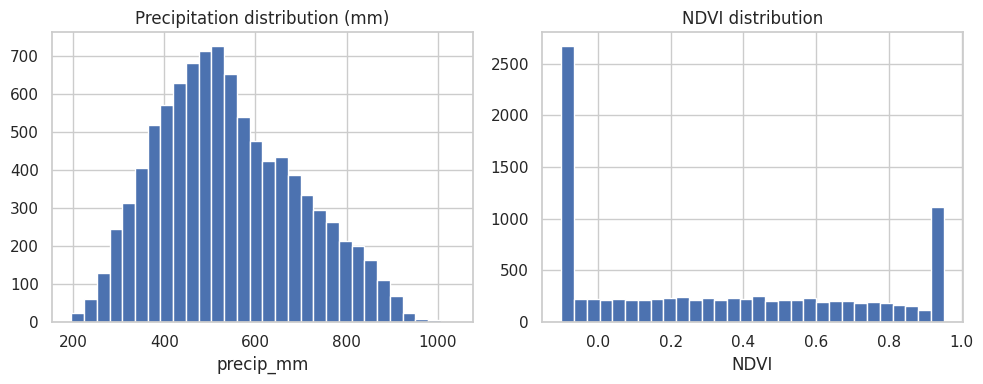

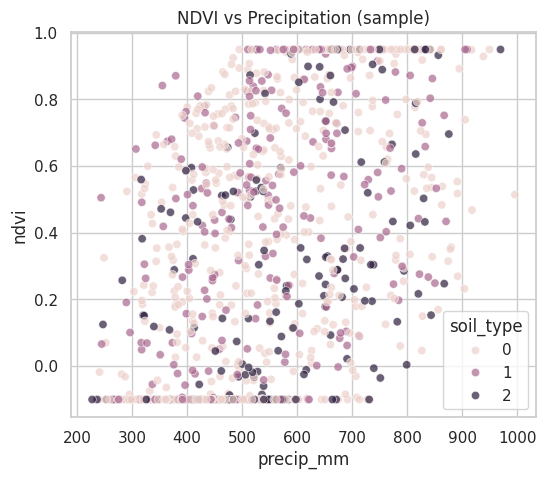

In [3]:
# 3. Quick EDA: distributions and relationships
print('NDVI summary:')
display(df['ndvi'].describe())

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(df['precip_mm'], bins=30)
plt.title('Precipitation distribution (mm)')
plt.xlabel('precip_mm')

plt.subplot(1,2,2)
plt.hist(df['ndvi'], bins=30)
plt.title('NDVI distribution')
plt.xlabel('NDVI')
plt.tight_layout()
plt.show()

# NDVI vs Precip scatter (sample subset to reduce overplot)
sample = df.sample(1000, random_state=1)
plt.figure(figsize=(6,5))
sns.scatterplot(x='precip_mm', y='ndvi', hue='soil_type', data=sample, alpha=0.7)
plt.title('NDVI vs Precipitation (sample)')
plt.show()

In [4]:
# 4. Aggregate per pixel: compute mean annual NDVI and total annual precipitation
agg = df.groupby('pixel_id').agg(
    mean_ndvi=('ndvi','mean'),
    std_ndvi=('ndvi','std'),
    total_precip=('precip_mm','sum'),
    mean_precip=('precip_mm','mean'),
    elevation=('elevation','first'),
    lat=('lat','first'),
    lon=('lon','first'),
    soil_type=('soil_type','first')
).reset_index()

print('Aggregated pixels shape:', agg.shape)
agg.head()

Aggregated pixels shape: (800, 9)


,pixel_id,mean_ndvi,std_ndvi,total_precip,mean_precip,elevation,lat,lon,soil_type
0,0,0.747186,0.176262,6758.551512,563.212626,287.800987,13.745401,82.072386,0
1,1,0.258147,0.209839,4284.134084,357.011174,485.057343,19.507143,76.525390,0
2,2,0.547625,0.203107,5368.436805,447.369734,339.984603,17.319939,80.762884,0
3,3,0.413071,0.248504,5994.650195,499.554183,532.494459,15.986585,81.067150,0
4,4,0.912400,0.068796,8043.878211,670.323184,104.135764,11.560186,79.241307,1


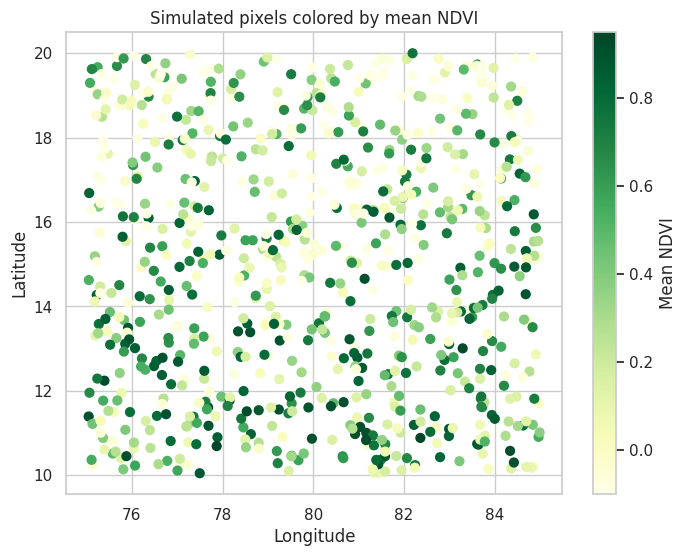

In [5]:
# 5. Visualize aggregated spatial scatter (lat/lon colored by mean NDVI)
plt.figure(figsize=(8,6))
sc = plt.scatter(agg['lon'], agg['lat'], c=agg['mean_ndvi'], cmap='YlGn', s=40)
plt.colorbar(sc, label='Mean NDVI')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Simulated pixels colored by mean NDVI')
plt.show()

In [6]:
# 6. Prepare features and target for ML
# We'll create two tasks:
#  - Regression: predict mean_ndvi (continuous) from environmental predictors
#  - Classification: predict whether pixel is 'healthy' vegetation (mean_ndvi > threshold)

X = agg[['total_precip','mean_precip','elevation','soil_type','lat','lon','std_ndvi']].copy()
X = pd.get_dummies(X, columns=['soil_type'], prefix='soil')

y_reg = agg['mean_ndvi']
threshold = 0.4
y_clf = (agg['mean_ndvi'] > threshold).astype(int)

# Train/test split
X_train, X_test, yreg_train, yreg_test, yclf_train, yclf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

print('X_train shape:', X_train.shape, 'X_test shape:', X_test.shape)

X_train shape: (640, 9) X_test shape: (160, 9)


In [7]:
# 7. Scaling (for linear models) - not necessary for tree-based models but we'll show it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 8. Regression models: Linear Regression and Random Forest Regressor
lr = LinearRegression()
rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)

lr.fit(X_train_scaled, yreg_train)
rf_reg.fit(X_train, yreg_train)  # trees use unscaled features

# Predictions
y_pred_lr = lr.predict(X_test_scaled)
y_pred_rf = rf_reg.predict(X_test)

print('Linear Regression R2:', r2_score(yreg_test, y_pred_lr).round(4))
print('Random Forest R2:', r2_score(yreg_test, y_pred_rf).round(4))
print('Random Forest RMSE:', np.sqrt(mean_squared_error(yreg_test, y_pred_rf)).round(4))

Linear Regression R2: 0.9681
Random Forest R2: 0.995
Random Forest RMSE: 0.0259


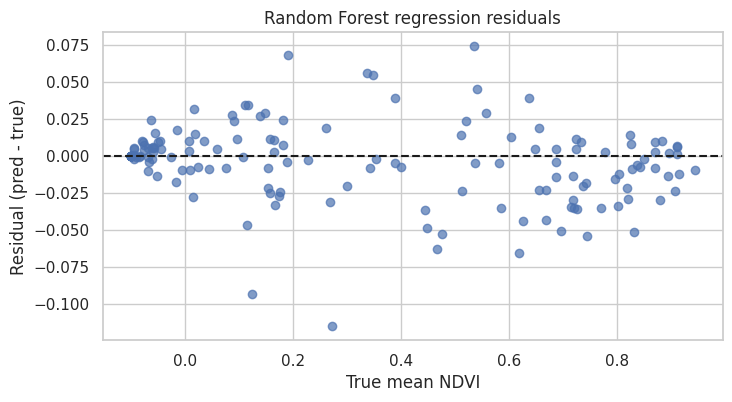

In [8]:
# 9. Regression residual plot
plt.figure(figsize=(8,4))
plt.scatter(yreg_test, y_pred_rf - yreg_test, alpha=0.7)
plt.axhline(0, color='k', linestyle='--')
plt.xlabel('True mean NDVI')
plt.ylabel('Residual (pred - true)')
plt.title('Random Forest regression residuals')
plt.show()

Accuracy: 0.9812

Classification report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.98        95
           1       0.96      1.00      0.98        65

    accuracy                           0.98       160
   macro avg       0.98      0.98      0.98       160
weighted avg       0.98      0.98      0.98       160



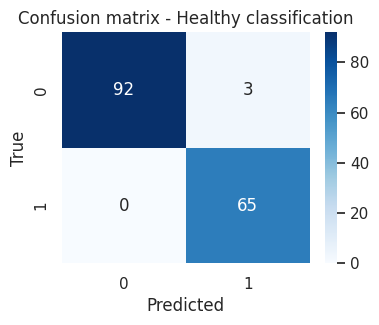

In [13]:
# 10. Classification: Random Forest Classifier to detect 'healthy' pixels
rf_clf = RandomForestClassifier(n_estimators=200, random_state=42)
rf_clf.fit(X_train, yclf_train)

yclf_pred = rf_clf.predict(X_test)
print('Accuracy:', round(accuracy_score(yclf_test, yclf_pred), 4))

print('\nClassification report:\n', classification_report(yclf_test, yclf_pred))

cm = confusion_matrix(yclf_test, yclf_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion matrix - Healthy classification')
plt.show()

Top features:
elevation       0.722937
std_ndvi        0.079694
total_precip    0.057386
lat             0.053098
mean_precip     0.049289
lon             0.023007
soil_2          0.006813
soil_1          0.005313
soil_0          0.002462
dtype: float64


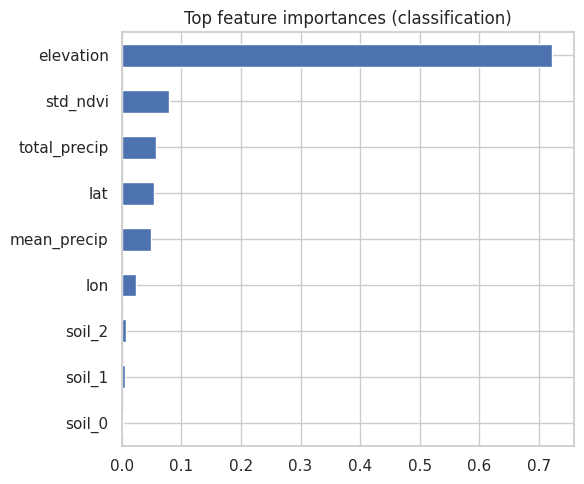

In [10]:
# 11. Feature importance from Random Forest (classification)
feat_imp = pd.Series(rf_clf.feature_importances_, index=X.columns).sort_values(ascending=False)
print('Top features:')
print(feat_imp.head(10))

plt.figure(figsize=(6,5))
feat_imp.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top feature importances (classification)')
plt.tight_layout()
plt.show()

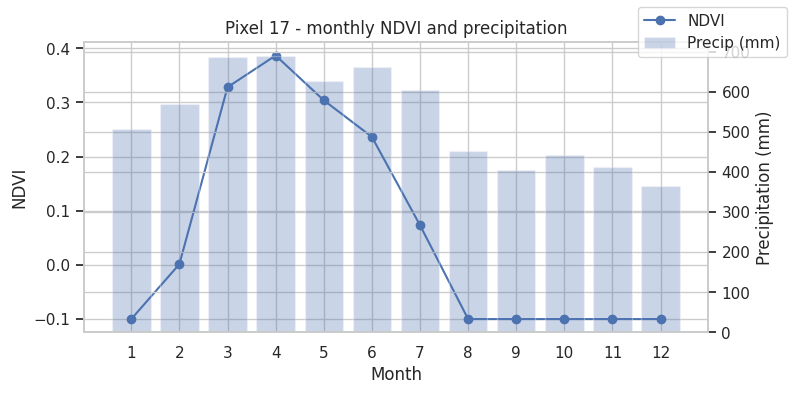

In [11]:
# 12. Quick per-pixel time series example
# Pick one pixel and plot its monthly NDVI & precip
pixel_to_plot = df['pixel_id'].unique()[17]
sub = df[df['pixel_id']==pixel_to_plot].sort_values('month')

fig, ax1 = plt.subplots(figsize=(8,4))
ax1.plot(sub['month'], sub['ndvi'], marker='o', label='NDVI')
ax1.set_xlabel('Month')
ax1.set_ylabel('NDVI')
ax2 = ax1.twinx()
ax2.bar(sub['month'], sub['precip_mm'], alpha=0.3, label='Precip (mm)')
ax2.set_ylabel('Precipitation (mm)')
plt.title(f'Pixel {pixel_to_plot} - monthly NDVI and precipitation')
ax1.set_xticks(range(1,13))
fig.legend(loc='upper right')
plt.tight_layout()
plt.show()